In [1]:
# we want to compare PSDs with the magnet vs PSDs without for UNO

In [41]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
# plt.rcParams['figure.figsize'] = (3,2)
# plt.rcParams["figure.dpi"] = 300
import os

In [42]:
magDF = pd.read_csv('./26040201.CSV')
# magDF

overDF = pd.read_csv('./26040201A.CSV')

nomagDF = pd.read_csv('./26040218.CSV')
nomagDF

,timecode,seconds,lat,lat_dir,lon,lon_dir,sensor
0,260402_182110_000,66070.000,4159.9893,N,8739.4141,W,8265
1,260402_182110_439,66070.438,4159.9893,N,8739.4141,W,8293
2,260402_182110_449,66070.445,4159.9893,N,8739.4141,W,8288
3,260402_182110_459,66070.461,4159.9893,N,8739.4141,W,8283
4,260402_182110_469,66070.469,4159.9893,N,8739.4141,W,8287
...,...,...,...,...,...,...,...
160729,260402_184940_678,67780.680,4159.9819,N,8739.4199,W,4809
160730,260402_184940_688,67780.688,4159.9819,N,8739.4199,W,5014
160731,260402_184940_698,67780.695,4159.9819,N,8739.4199,W,4816
160732,260402_184940_708,67780.711,4159.9819,N,8739.4199,W,4818


In [49]:
magSeconds = np.array(magDF['seconds'])
magSensor = np.array(magDF['sensor'])

overSeconds = np.array(overDF['seconds'])
overSensor = np.array(overDF['sensor'])

nomagSeconds = np.array(nomagDF['seconds'])
nomagSensor = np.array(nomagDF['sensor'])

In [50]:
overSeconds = overSeconds[200000:-200000]
overSensor = overSensor[200000:-200000]

In [51]:
downoverSec = overSeconds[::5]
downoverSens = overSensor[::5]

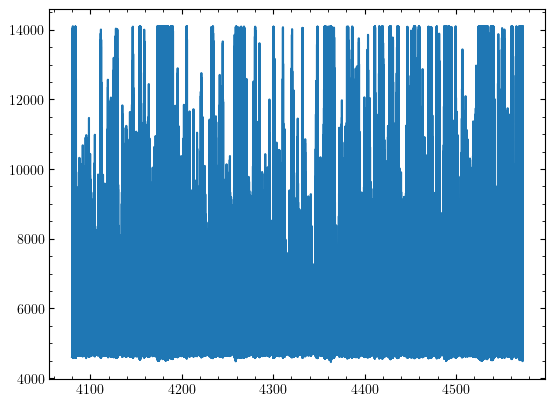

In [52]:
plt.plot(magSeconds,magSensor)

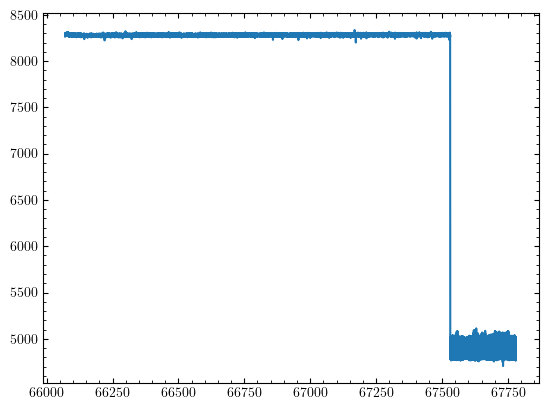

In [53]:
plt.plot(nomagSeconds,nomagSensor)

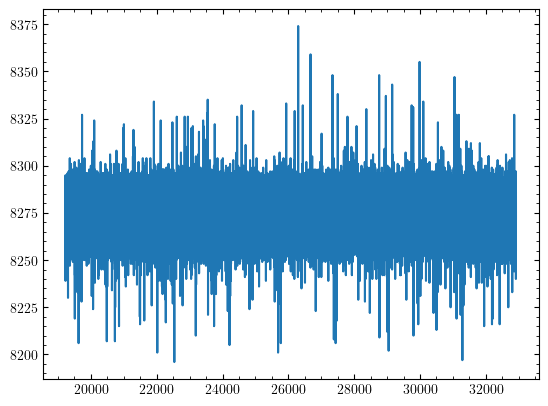

In [54]:
plt.plot(overSeconds,overSensor)

In [55]:
magVolt = magSensor * 5 / 16383
nomagVolt = nomagSensor * 5 / 16383

overVolt = overSensor * 5 / 16383

downoverVolt = downoverSens * 5 / 16383

Text(0, 0.5, 'voltage')

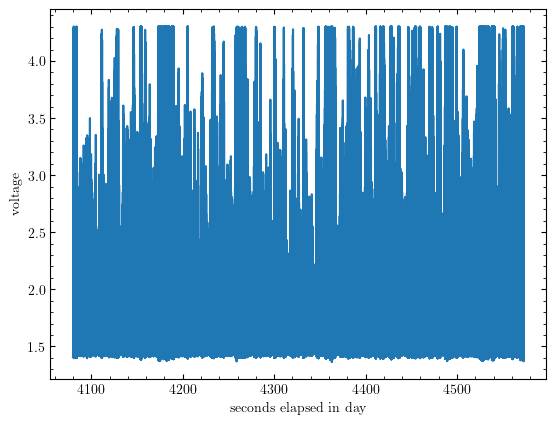

In [74]:
plt.plot(magSeconds,magVolt)
plt.xlabel('seconds elapsed in day')
plt.ylabel('voltage')

Text(0, 0.5, 'voltage')

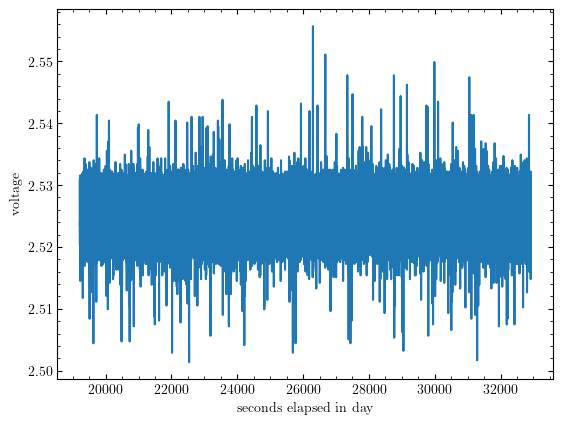

In [57]:
plt.plot(overSeconds,overVolt)
plt.xlabel('seconds elapsed in day')
plt.ylabel('voltage')

In [66]:
nomagmask = nomagVolt > 2.5

nomagSeconds = nomagSeconds[nomagmask]
nomagVolt = nomagVolt[nomagmask]

Text(0, 0.5, 'voltage')

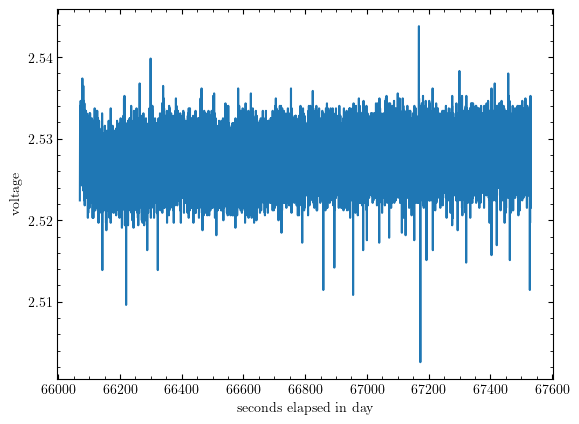

In [68]:
plt.plot(nomagSeconds,nomagVolt)
plt.xlabel('seconds elapsed in day')
plt.ylabel('voltage')

In [71]:
adjnomagVolt = nomagVolt - nomagVolt.mean()

Text(0, 0.5, 'voltage')

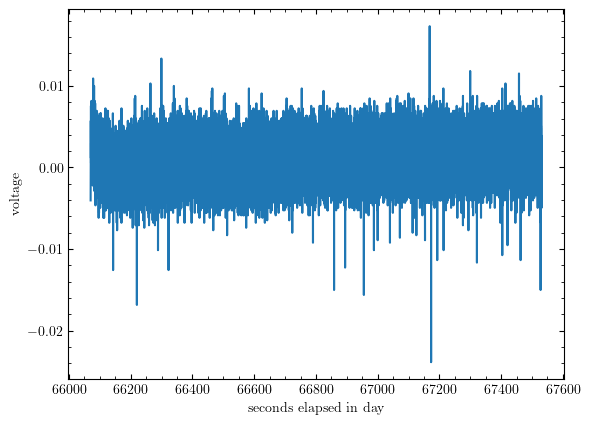

In [73]:
plt.plot(nomagSeconds,adjnomagVolt)
plt.xlabel('seconds elapsed in day')
plt.ylabel('voltage')

Text(0, 0.5, 'voltage')

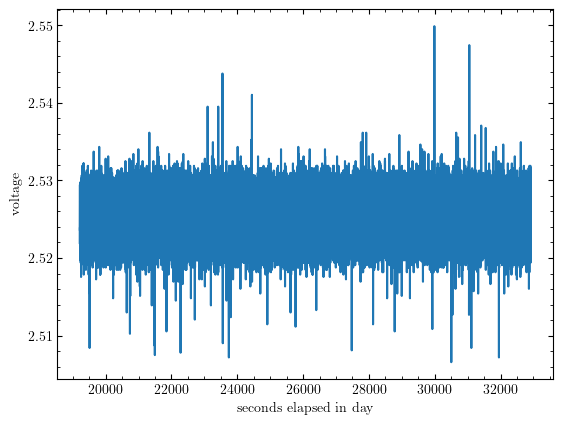

In [75]:
plt.plot(downoverSec,downoverVolt)
plt.xlabel('seconds elapsed in day')
plt.ylabel('voltage')

Text(0, 0.5, 'voltage')

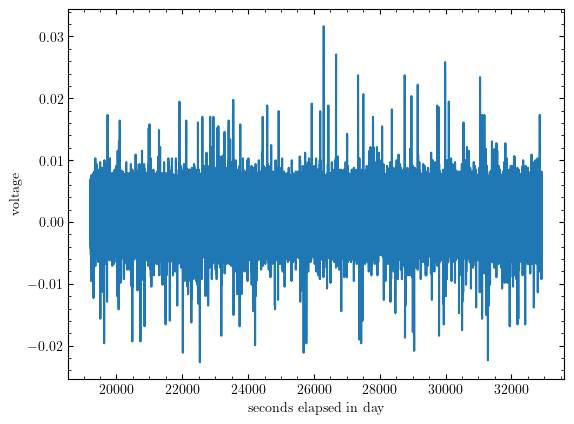

In [76]:
adjOverVolt = overVolt - overVolt.mean()
plt.plot(overSeconds,adjOverVolt)
plt.xlabel('seconds elapsed in day')
plt.ylabel('voltage')

In [85]:
fs = 100
nper = 300
magF, magPSD = sp.signal.welch(magVolt,fs=fs,nperseg=nper)
# nomagF, nomagPSD = sp.signal.welch(nomagSensor,fs=fs,nperseg=150)
overF,overPSD = sp.signal.welch(adjOverVolt,fs=fs,nperseg=nper)

nomagF,nomagPSD = sp.signal.welch(nomagVolt,fs=fs,nperseg=nper)

Text(0.5, 0, 'Hz')

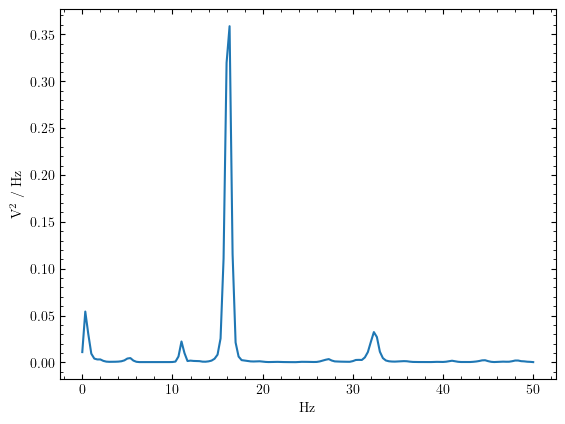

In [86]:
plt.plot(magF,magPSD)
# plt.plot(nomagF,nomagPSD)
plt.ylabel(r'V$^2$ / Hz')
plt.xlabel('Hz')

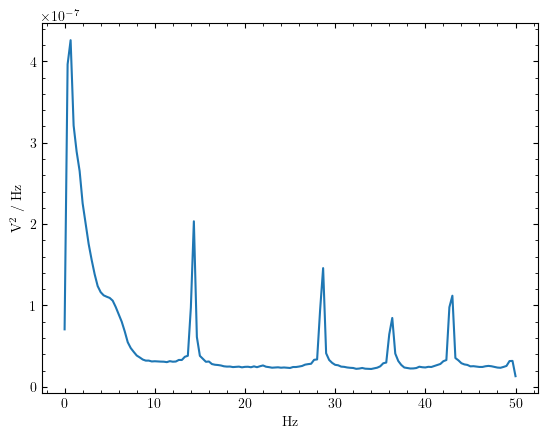

In [87]:
plt.plot(overF,overPSD)
plt.ylabel(r'V$^2$ / Hz')
plt.xlabel('Hz')
# plt.semilogx()
plt.show()

In [88]:
downF,downPSD = sp.signal.welch(downoverVolt,fs=20,nperseg=300)

Text(0.5, 0, 'Hz')

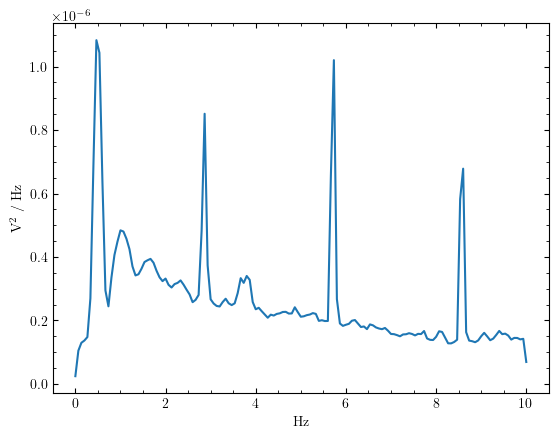

In [89]:
plt.plot(downF,downPSD)
plt.ylabel(r'V$^2$ / Hz')
plt.xlabel('Hz')

Text(0.5, 0, 'Hz')

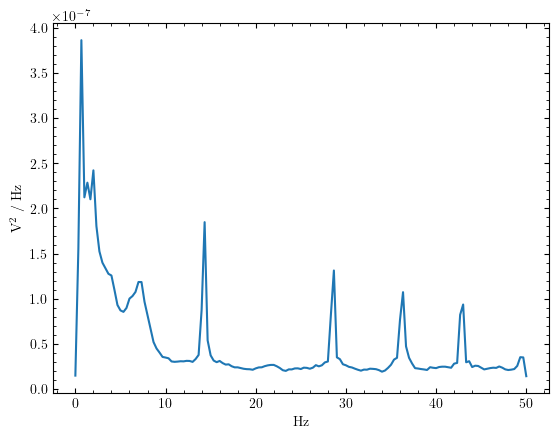

In [90]:
plt.plot(nomagF,nomagPSD)
plt.ylabel(r'V$^2$ / Hz')
plt.xlabel('Hz')

In [91]:
compPSD = overPSD - nomagPSD

Text(0.5, 0, 'Hz')

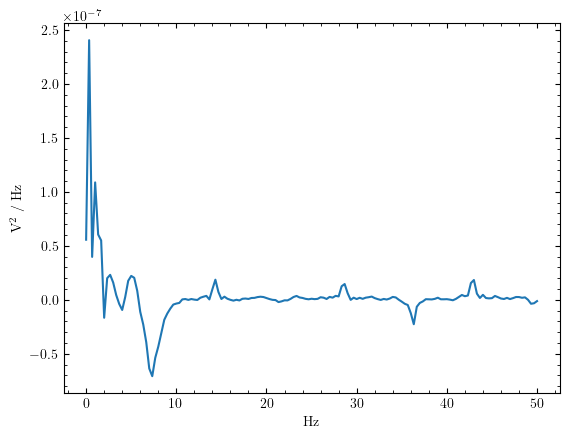

In [92]:
plt.plot(overF,compPSD)
plt.ylabel(r'V$^2$ / Hz')
plt.xlabel('Hz')